In [4]:
import functools
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import torch


First, I'll define a function for getting the trajectory give nthe things we'll vary over this problem. We'll start at $(5, 10)$ and optimize until we get within $0.1$ of $(0, 0)$, the global optimum.

In [5]:
@functools.cache
def trajectory(m, weight_decay, objective, maximize):
    theta = torch.tensor([5, 10], dtype=torch.float32, requires_grad=True)
    optim = torch.optim.SGD(
        [theta], momentum=m, weight_decay=weight_decay, maximize=maximize
    )
    steps = []
    while theta.norm() > 0.01:
        steps.append(theta.detach().clone().numpy())
        optim.zero_grad()
        y = objective(*theta)
        y.backward()
        optim.step()
    return np.array(steps)

Then we can take the function over each value of the hyperparameters, $\mu$ for momentum and $\lambda$ for weight decay. I'll use $f(x, y) = x^2 + y^2$ first:

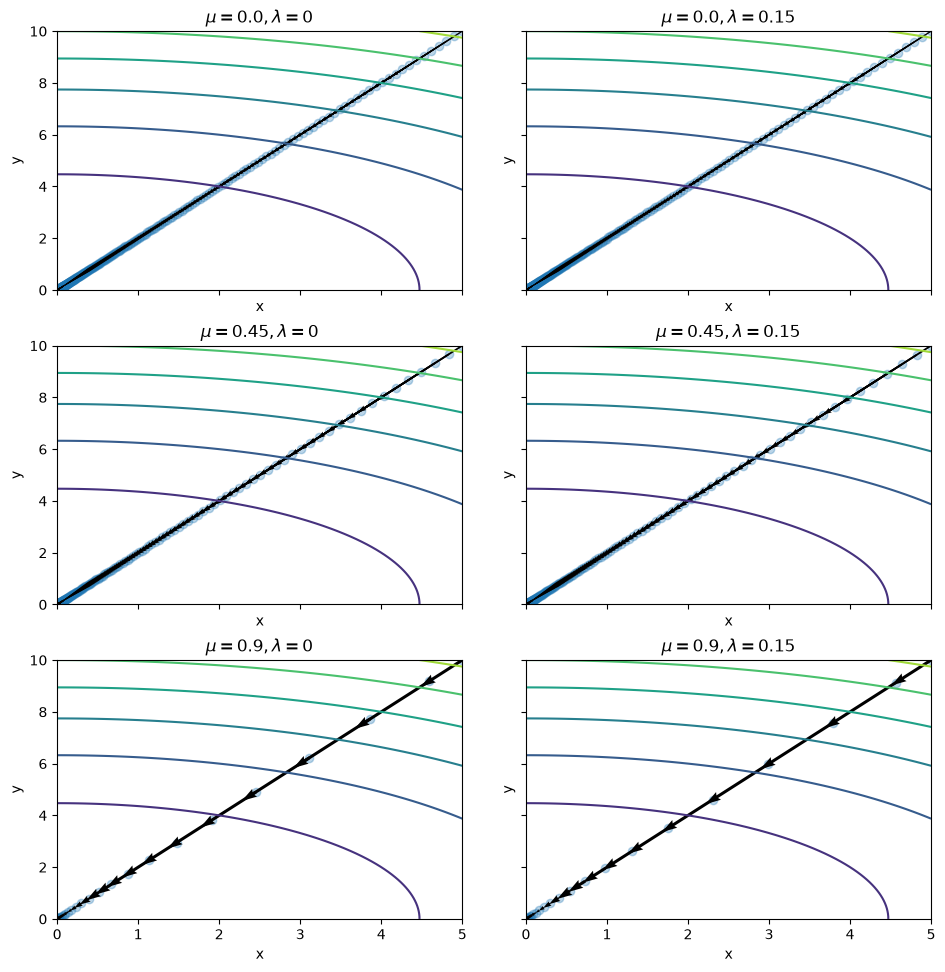

In [34]:
momentums = np.linspace(0, 0.9, 3)
weight_decays = [0, 0.15]


def pos_func(x, y):
    return x**2 + y**2


# setup for the contour plot
x, y = np.meshgrid(np.linspace(0, 5, 100), np.linspace(0, 10, 100))
z = pos_func(x, y)

# setup for trajectory plots
fig, ax = plt.subplots(len(momentums), len(weight_decays), sharex=True, sharey=True)
fig.set_size_inches(10, 10)
plt.tight_layout(pad=3.0)

for (i_m, m), (i_wd, wd) in product(enumerate(momentums), enumerate(weight_decays)):
    steps_np = trajectory(m, wd, pos_func, maximize=False)[::10, :]

    curr_ax = ax[i_m, i_wd]

    curr_ax.scatter(steps_np[:, 0], steps_np[:, 1], alpha=0.3) # points

    # arrows
    dx = np.diff(steps_np[:, 0])
    dy = np.diff(steps_np[:, 1])
    curr_ax.quiver(steps_np[:-1, 0], steps_np[:-1, 1], dx, dy, angles="xy") 

    curr_ax.contour(x, y, z, label=r"$f(x,y)=x^2 + y^2$")

    curr_ax.set_xlabel("x")
    curr_ax.set_ylabel("y")

    ax[i_m, i_wd].set_title(rf"$\mu = {m}, \lambda = {wd}$")


And then setting maximize for the new objective $f(x,y) = -x^2 - y^2$ setting `maximize=True`:

Text(0.5, 1.0, '$\\mu = 0.9, \\lambda = 0.15$')

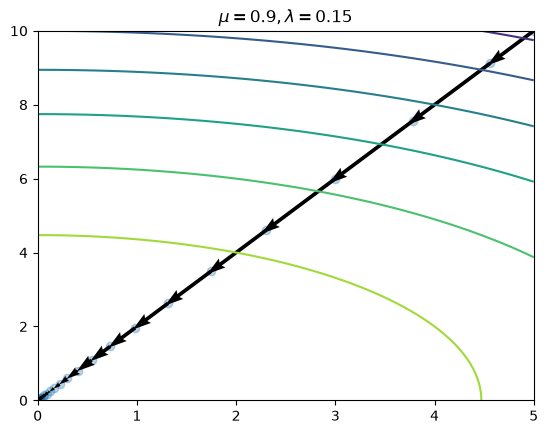

In [42]:
def neg_func(x, y):
    return -(x**2) - y**2


# setup for the contour plot
x, y = np.meshgrid(np.linspace(0, 5, 100), np.linspace(0, 10, 100))
z = neg_func(x, y)

# setup for trajectory plots
fig, ax = plt.subplots()

steps_np = trajectory(m, wd, neg_func, maximize=True)[::10, :]

ax.scatter(steps_np[:, 0], steps_np[:, 1], alpha=0.3)

ax.quiver(steps_np[:-1, 0], steps_np[:-1, 1], dx, dy, angles="xy")
dx = np.diff(steps_np[:, 0])
dy = np.diff(steps_np[:, 1])

ax.contour(x, y, z, label=r"$f(x,y)=-x^2 - y^2$")

ax.set_title(rf"$\mu = {m}, \lambda = {wd}$")

We can see that the momentum changes the speed at which the optimizer converges; setting a higher $\mu$ meant that the optimizer accumulated greater magnitude gradient steps in $g_t$, which led to bigger updates at each step.

For weight decay, it's harder to see the difference. However, we can look at the number of steps each took.

The number of steps needed to get within $0.1$ of $(0,0)$ without weight decay was:

In [ ]:
trajectory(0, 0, pos_func, maximize=False).shape[0]

3507

Whereas the number of steps with weight decay $\lambda=0.1$ was 

In [ ]:
trajectory(0, 0.1, pos_func, maximize=False).shape[0]

3340

So setting weight decay higher slightly increased the speed of the optimizer for this function. This was because the gradient of the loss function had a larger magnitude when weight decay was used; like with momentum, our update was the same as when weight decay was $0$, but with an added term in the same direction from the weight decay. 
This caused the magnitude of each step size to increase, which led to fewer steps/faster convergence.

On the other hand, setting `maximize=True` didn't make a difference, since the sign flip in SGD was counteracted by the sign flip in $f(x, y)$. The sign of the gradient flipped, but kept the magnitude and direction, and SGD flipping the sign of the gradient for `maximize=True` meant that the updates were the same throughout.

To confirm, we can look at the # of steps for each option.

Number of steps on negative objective with `maximize=True`

In [ ]:
trajectory(0, 0, pos_func, maximize=False).shape[0]

3507

Number of steps on positive objective with `maximize=False`

In [ ]:
trajectory(0, 0, neg_func, maximize=True).shape[0]

3507

Which are the same.